# Enhancing Automatic Speech Recognition for Child Speech in Low-Resource Languages

### Thesis Evaluation Pipeline


## Phase 1: Environment Setup & Configuration


In [1]:
from google.colab import userdata
import os

try:
    gh_token = userdata.get('GH_TOKEN')
    !git clone https://{gh_token}@github.com/minhashemi/bsc-thesis.git
except Exception:
    print('GH_TOKEN not found!')

Cloning into 'bsc-thesis'...
remote: Enumerating objects: 494, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 494 (delta 78), reused 89 (delta 39), pack-reused 343 (from 1)
Receiving objects: 100% (494/494), 37.69 MiB | 22.40 MiB/s, done.
Resolving deltas: 100% (273/273), done.


In [5]:
%cd /content/bsc-thesis
!git pull origin main
!pip install --upgrade pip wheel "setuptools<82"
!apt-get install -y cmake libportaudio2
!apt-get install -y unar
!pip install -r requirements.txt

/content/bsc-thesis
From https://github.com/minhashemi/bsc-thesis
 * branch            main       -> FETCH_HEAD
Already up to date.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libportaudio2 is already the newest version (19.6.0-1.1).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unar is already the newest version (1.10.1-2build11).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
  Cloning https://github.com/openai/whisper.git to /tmp/pip-install-53qantcm/openai-whisper_d0feb29af6a545d18e01a54e4a12553f
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-install-53qantcm/openai-whisper_d0feb29af6a545d18e01a54e4a12553f
  Resolved https://github.com/openai/whisper.git to commit 04f449b8a437f1bbd3db

In [2]:
from google.colab import userdata
import os

try:
    os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
except:
    pass
try:
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
except:
    pass

In [ ]:
!python main.py --list-profiles

Available profiles:
  - raw
  - classic
  - llm
  - vosk
  - gemini_3.5_direct
  - gemini_3_direct
  - gemini_2.5_direct
  - whisper_large
  - whisper_fine_tuned
  - qwen_direct


## Phase 2: Baseline ASR Evaluation


### Vosk (Offline ASR)


In [ ]:
!python main.py --profile vosk

Loading configuration profile: 'vosk'
--- Initializing Pipeline ---
Profile:         vosk
Source:          cached
Post-processing: none
Loading Vosk model from models/vosk-model-small-fa-0.5...
LOG (VoskAPI:ReadDataFiles():model.cc:213) Decoding params beam=10 max-active=3000 lattice-beam=2
LOG (VoskAPI:ReadDataFiles():model.cc:216) Silence phones 1:2:3:4:5:6:7:8:9:10
LOG (VoskAPI:RemoveOrphanNodes():nnet-nnet.cc:948) Removed 1 orphan nodes.
LOG (VoskAPI:RemoveOrphanComponents():nnet-nnet.cc:847) Removing 2 orphan components.
LOG (VoskAPI:Collapse():nnet-utils.cc:1488) Added 1 components, removed 2
LOG (VoskAPI:ReadDataFiles():model.cc:248) Loading i-vector extractor from models/vosk-model-small-fa-0.5/ivector/final.ie
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:183) Computing derived variables for iVector extractor
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:204) Done.
LOG (VoskAPI:ReadDataFiles():model.cc:282) Loading HCL and G from models/vosk-model-small-fa-0.

### Whisper Base


In [ ]:
!python main.py --profile raw

Loading configuration profile: 'raw'
--- Initializing Pipeline ---
Profile:         raw
Source:          cached
Post-processing: none
Loading Whisper model (base)...

--- Starting Transcription ---

Loading dataset from local cache
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Hypothesis:      بلوچ فراموزگار هوشی ربی نامانا روز جاشن ارفپا مباراکیست بایمو.
  Metrics:
    - WER: 92.86%
    - CER: 39.34%
    - Levenshtein Dist: 13
------------------------------
Sample 3:
  Reference: کلمه‌ی ناس بذار ببینم این الف و لام ناسه ولی می‌خونیم ناس.
  Hypothesis:      خاله می یه نوش. این بزم بی بنام این الفو. لام نوشه وانه میخونم نوش.
  Metrics:
    - WER: 108.33%
    - CER: 49.12%
    - Levenshtein Dist: 13
------------------------------
Sample 4:
  Reference: ماجرا داریم خیلی هم عالی ماجراهای باحال، الان هم دیگه وقتش شده جابه‌جا بشیم حالا.
  Hypothesis:      مجرز و ادن خیلی اموری مجره هایبا ها. آلنام دیگه با کشده جالجه دیشی مانا.
  Metrics:
    - WER: 

### Whisper Large-v3


In [ ]:
!python main.py --profile whisper_large

Loading configuration profile: 'whisper_large'
--- Initializing Pipeline ---
Profile:         whisper_large
Source:          cached
Post-processing: none
Loading Whisper model (large-v3)...

--- Starting Transcription ---

Loading dataset from local cache
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Hypothesis:      به لطف آموزگار، حشیار و بینام منم. روز جشن علف با مبارک است بر ما.
  Metrics:
    - WER: 28.57%
    - CER: 6.56%
    - Levenshtein Dist: 4
------------------------------
Sample 3:
  Reference: کلمه‌ی ناس بذار ببینم این الف و لام ناسه ولی می‌خونیم ناس.
  Hypothesis:      کلمه ناس. این بیزن ببینم. این الف و لام ناسه. و اینه می‌خونیم ناس.
  Metrics:
    - WER: 41.67%
    - CER: 22.81%
    - Levenshtein Dist: 5
------------------------------
Sample 4:
  Reference: ماجرا داریم خیلی هم عالی ماجراهای باحال، الان هم دیگه وقتش شده جابه‌جا بشیم حالا.
  Hypothesis:      مجره زاریم خیلی هم و حالی مجره‌های باهار. الانم دیگه وقت شده جا به جا بش

## Phase 3: ASR + LLM Post-Processing


### Whisper Base ASR + Gemini Error Correction


In [ ]:
!python main.py --profile llm

Loading configuration profile: 'llm'
--- Initializing Pipeline ---
Profile:         llm
Source:          cached
Post-processing: llm
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading weights: 100% 1096/1096 [00:01<00:00, 1008.89it/s]

--- Starting Transcription ---

Loading dataset from local cache
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Raw Hypothesis:  به لتف آموزگار هشیار و بینا مرم روز جشن الفبا مبارک است و ما
  Corrected Hyp:   به لطف آموزگار هشیار و بینا امروز روز جشن الفبا مبارک است و ما
  Metrics:
    - WER: 14.29%
    - CER: 9.84%
    - Levenshtein Dist: 2
-----------

### Whisper Base ASR + Rule-Based (Classic) Correction

In [ ]:
!python main.py --profile classic


Loading configuration profile: 'classic'
--- Initializing Pipeline ---
Profile:         classic
Source:          cached
Post-processing: classic
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading weights: 100% 1096/1096 [00:00<00:00, 5299.34it/s]

--- Starting Transcription ---

Loading dataset from local cache
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Raw Hypothesis:  به لتف آموزگار هشیار و بینا مرم روز جشن الفبا مبارک است و ما
  Corrected Hyp:   به لتف آموزگار هشیار و بینا مرم روز جشن الفبا مبارک است و ما
  Metrics:
    - WER: 21.43%
    - CER: 6.56%
    - Levenshtein Dist: 3
-

## Phase 4: Multimodal LLM Direct Audio Feed


### Gemini 3.5 Flash Direct


In [ ]:
!python main.py --profile gemini_3.5_direct

Loading configuration profile: 'gemini_3.5_direct'
--- Initializing Pipeline ---
Profile:         gemini_3.5_direct
Source:          cached
Post-processing: none
Loading Gemini Direct Model (gemini-3.5-flash)...

--- Starting Transcription ---

Loading dataset from local cache
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Hypothesis:      به نام آموزگار هوشیار و بینای منم روز جشن الفبا مبارک است بر ما
  Metrics:
    - WER: 21.43%
    - CER: 8.20%
    - Levenshtein Dist: 3
------------------------------
Sample 3:
  Reference: کلمه‌ی ناس بذار ببینم این الف و لام ناسه ولی می‌خونیم ناس.
  Hypothesis:      کلمه ناس این بذار ببینم این الف و لام ناسه و این می‌خونیم ناس
  Metrics:
    - WER: 33.33%
    - CER: 15.79%
    - Levenshtein Dist: 4
------------------------------
Sample 4:
  Reference: ماجرا داریم خیلی هم عالی ماجراهای باحال، الان هم دیگه وقتش شده جابه‌جا بشیم حالا.
  Hypothesis:      ماجرا داریم خیلی هم عالی ماجراهای باحال الان هم دیگه وقتش 

### Gemini 2.5 Flash Direct


In [ ]:
!python main.py --profile gemini_2.5_direct

Loading configuration profile: 'gemini_2.5_direct'
--- Initializing Pipeline ---
Profile:         gemini_2.5_direct
Source:          cached
Post-processing: none
Loading Gemini Direct Model (gemini-2.5-flash)...

--- Starting Transcription ---

Loading dataset from local cache
Sample 1: transcribing...
[Gemini Direct Transcribe Error: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}]
Sample 1:
  Reference: به لطف آموزگار هشیار و بینا منم. روز جشن الفبا مبارک است بر ما.
  Hypothesis:      
  Metrics:
    - WER: 100.00%
    - CER: 100.00%
    - Levenshtein Dist: 14
------------------------------
Sample 3:
  Reference: کلمه‌ی ناس بذار ببینم این الف و لام ناسه ولی می‌خونیم ناس.
  Hypothesis:      کلمه ناس. این بذار ببینم این الف و لام ناسه ولی میخونیم ناس.
  Metrics:
    - WER: 25.00%
    - CER: 12.28%
    - Levenshtein Dist: 3
------------------

### Qwen2-Audio (Local Open-Weight)


In [ ]:
!python main.py --profile qwen_direct

Loading configuration profile: 'qwen_direct'
--- Initializing Pipeline ---
Profile:         qwen_direct
Source:          cached
Post-processing: none
Loading Qwen Audio Model (Qwen/Qwen2-Audio-7B-Instruct)... This requires significant VRAM.
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
preprocessor_config.json: 100% 342/342 [00:00<00:00, 1.71MB/s]
config.json: 100% 853/853 [00:00<00:00, 4.17MB/s]
tokenizer_config.json: 100% 638k/638k [00:00<00:00, 127MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 76.6MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 136MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 68.0MB/s]
model.safeten

## Phase 5: Results & Visual Comparison


EVALUATION RESULTS SUMMARY
          Profile         Model    WER (%)    CER (%)   Avg Lev  Samples
      qwen_direct    qwen_local 147.921950 128.721532 23.307692       13
              raw       whisper 102.771469  50.252399 18.400000       10
             vosk          vosk  94.688645  66.275530 16.846154       13
          classic       whisper  80.757182  35.180746 14.000000       13
              llm       whisper  68.879840  31.337027 11.769231       13
    whisper_large       whisper  54.894791  21.907637  9.153846       13
gemini_2.5_direct gemini_direct  34.554456  21.541686  5.692308       13
gemini_3.5_direct gemini_direct  27.518434  12.896901  5.000000       13



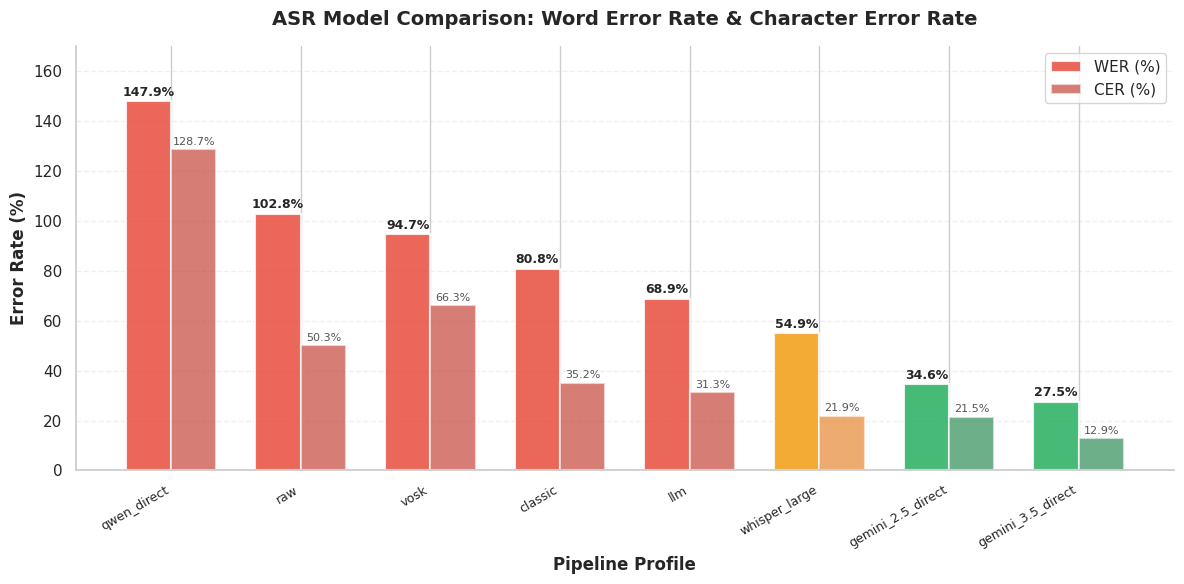

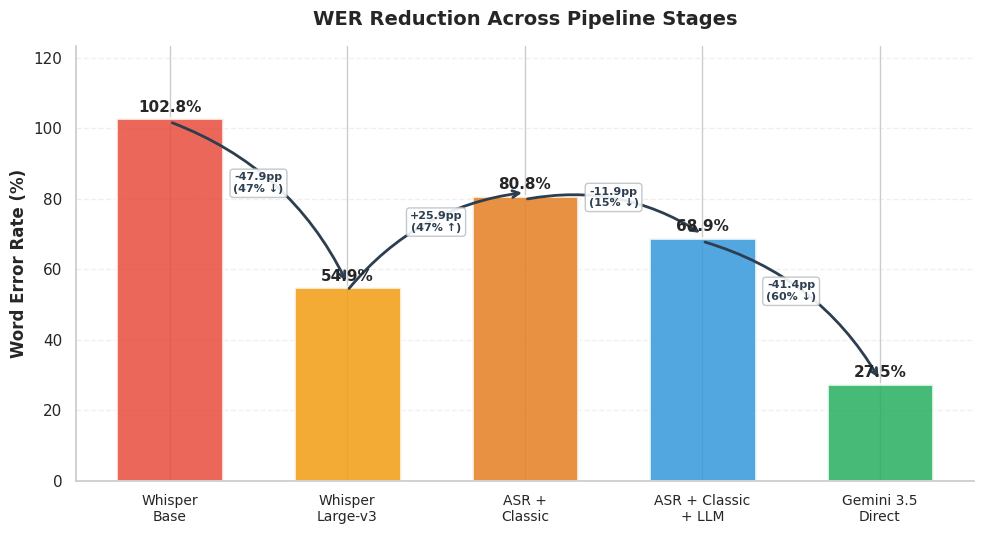

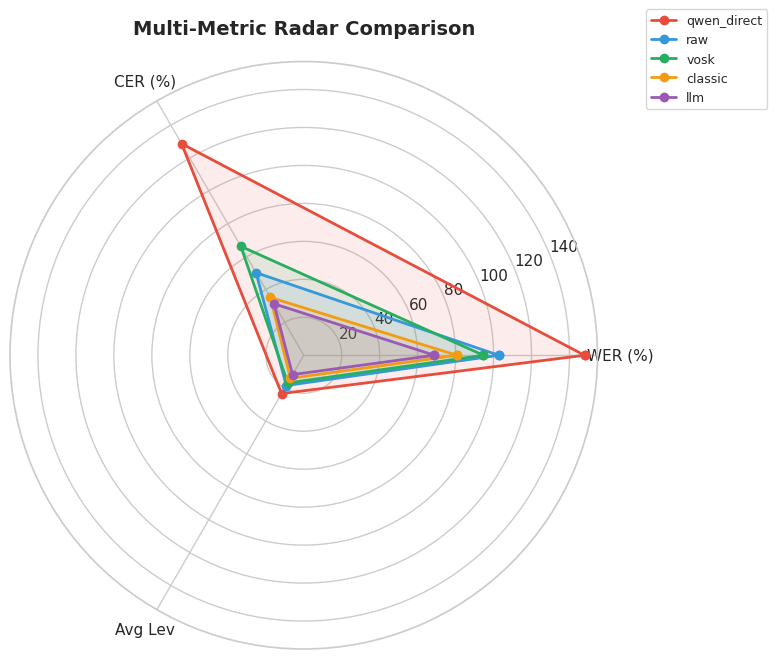

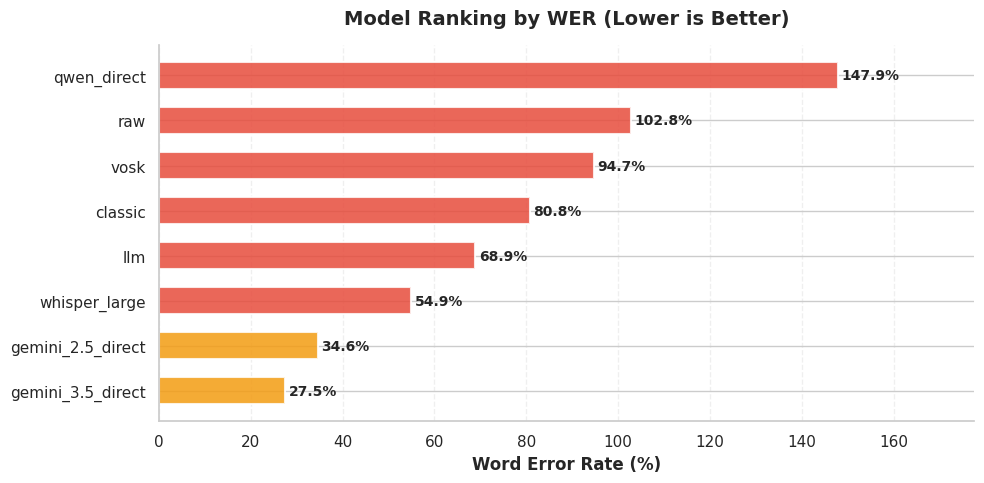

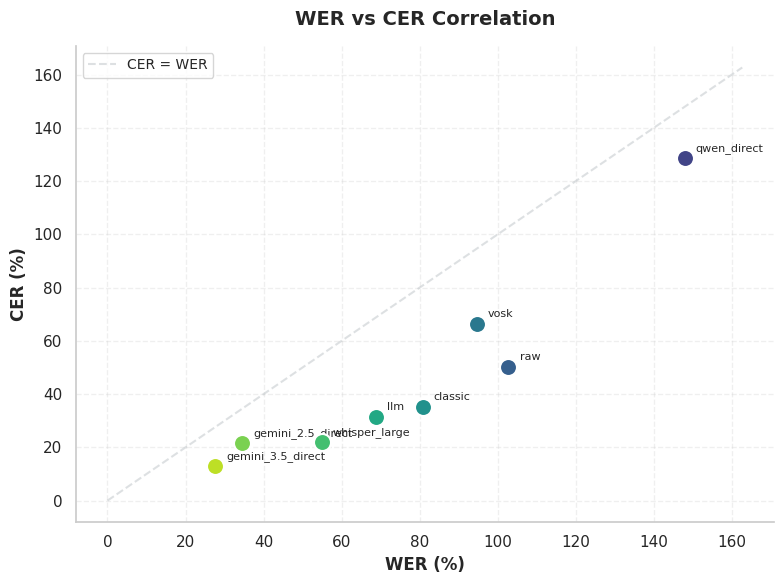

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

results_file = "evaluation_results.json"

if not os.path.exists(results_file):
    print("No evaluation_results.json found. Run evaluation cells first.")
else:
    with open(results_file, "r") as f:
        data = json.load(f)

    # ── Build DataFrame ──
    records = []
    for profile, metrics in data.items():
        if "(test)" in profile:
            continue  # Skip test-set entries for main comparison
        records.append({
            "Profile": profile,
            "Model": metrics.get("model", "unknown"),
            "WER (%)": metrics["avg_wer"] * 100,
            "CER (%)": metrics["avg_cer"] * 100,
            "Avg Lev": metrics.get("avg_lev", 0),
            "Samples": metrics.get("samples", 0),
        })
    df = pd.DataFrame(records)
    df = df.sort_values("WER (%)", ascending=False).reset_index(drop=True)

    print("=" * 60)
    print("EVALUATION RESULTS SUMMARY")
    print("=" * 60)
    print(df.to_string(index=False))
    print()

    # ── Chart 1: Grouped Bar Chart (WER + CER) ──
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(df))
    width = 0.35

    # Color bars by performance tier
    def tier_color(wer, is_cer=False):
        if wer > 60: return '#c0392b' if is_cer else '#e74c3c'
        if wer > 35: return '#e67e22' if is_cer else '#f39c12'
        return '#1e8449' if is_cer else '#27ae60'

    wer_colors = [tier_color(w) for w in df["WER (%)"]]
    cer_colors = [tier_color(w, True) for w in df["WER (%)"]]

    bars1 = ax.bar(x - width/2, df["WER (%)"], width, color=wer_colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5, label='WER (%)')
    bars2 = ax.bar(x + width/2, df["CER (%)"], width, color=cer_colors, alpha=0.65,
                   edgecolor='white', linewidth=1.5, label='CER (%)')

    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#555')

    ax.set_xlabel('Pipeline Profile', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('ASR Model Comparison: Word Error Rate & Character Error Rate',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(df["Profile"], fontsize=9, rotation=30, ha='right')
    ax.legend(fontsize=11, loc='upper right')
    ax.set_ylim(0, max(df["WER (%)"]) * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig("chart_comparison.png", dpi=200)
    plt.show()

    # ── Chart 2: WER Reduction Waterfall ──
    # Select key pipeline stages
    stage_order = ["raw", "whisper_large", "classic", "llm", "gemini_3.5_direct"]
    stage_labels = ["Whisper\nBase", "Whisper\nLarge-v3", "ASR +\nClassic", "ASR + Classic\n+ LLM", "Gemini 3.5\nDirect"]
    stage_colors = ['#e74c3c', '#f39c12', '#e67e22', '#3498db', '#27ae60']

    stage_wers = []
    available_stages = []
    available_labels = []
    available_colors = []
    for s, l, c in zip(stage_order, stage_labels, stage_colors):
        if s in data:
            stage_wers.append(data[s]["avg_wer"] * 100)
            available_stages.append(s)
            available_labels.append(l)
            available_colors.append(c)

    if len(available_stages) >= 2:
        fig, ax = plt.subplots(figsize=(10, 5.5))
        bars = ax.bar(range(len(available_stages)), stage_wers, color=available_colors,
                      width=0.6, edgecolor='white', linewidth=2, alpha=0.85)

        for i in range(len(stage_wers) - 1):
            reduction = stage_wers[i] - stage_wers[i+1]
            pct = (reduction / stage_wers[i]) * 100 if stage_wers[i] > 0 else 0
            mid_y = (stage_wers[i] + stage_wers[i+1]) / 2
            if abs(reduction) > 0.5:
                sign = '-' if reduction > 0 else '+'
                arrow = '\u2193' if reduction > 0 else '\u2191'
                ax.annotate('', xy=(i+1, stage_wers[i+1] + 1), xytext=(i, stage_wers[i] - 1),
                           arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2,
                                          connectionstyle='arc3,rad=-0.2'))
                ax.text(i + 0.5, mid_y + 3, f'{sign}{abs(reduction):.1f}pp\n({abs(pct):.0f}% {arrow})',
                       ha='center', fontsize=8, fontweight='bold', color='#2c3e50',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                               edgecolor='#bdc3c7', alpha=0.9))

        for bar, val in zip(bars, stage_wers):
            ax.text(bar.get_x() + bar.get_width()/2., val + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_xticks(range(len(available_stages)))
        ax.set_xticklabels(available_labels, fontsize=10)
        ax.set_ylabel('Word Error Rate (%)', fontsize=12, fontweight='bold')
        ax.set_title('WER Reduction Across Pipeline Stages', fontsize=14, fontweight='bold', pad=15)
        ax.set_ylim(0, max(stage_wers) * 1.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig("chart_waterfall.png", dpi=200)
        plt.show()

    # ── Chart 3: Radar/Spider Chart ──
    metrics_for_radar = ["WER (%)", "CER (%)", "Avg Lev"]
    df_radar = df[df["Avg Lev"] > 0].head(5)  # Top 5 profiles with lev data

    if len(df_radar) >= 2:
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
        angles = np.linspace(0, 2 * np.pi, len(metrics_for_radar), endpoint=False).tolist()
        angles += angles[:1]

        radar_colors = ['#e74c3c', '#3498db', '#27ae60', '#f39c12', '#9b59b6']
        for idx, (_, row) in enumerate(df_radar.iterrows()):
            values = [row[m] for m in metrics_for_radar]
            values += values[:1]
            ax.plot(angles, values, 'o-', linewidth=2, label=row["Profile"],
                   color=radar_colors[idx % len(radar_colors)])
            ax.fill(angles, values, alpha=0.1, color=radar_colors[idx % len(radar_colors)])

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics_for_radar, fontsize=11)
        ax.set_title('Multi-Metric Radar Comparison', fontsize=14, fontweight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
        plt.tight_layout()
        plt.savefig("chart_radar.png", dpi=200)
        plt.show()

    # ── Chart 4: Horizontal Ranking ──
    fig, ax = plt.subplots(figsize=(10, 5))
    df_sorted = df.sort_values("WER (%)", ascending=True)
    colors = ['#27ae60' if w < 25 else '#f39c12' if w < 45 else '#e74c3c' for w in df_sorted["WER (%)"]]

    bars = ax.barh(df_sorted["Profile"], df_sorted["WER (%)"], color=colors,
                   edgecolor='white', linewidth=1.5, height=0.6, alpha=0.85)
    for bar, wer in zip(bars, df_sorted["WER (%)"]):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2.,
                f'{wer:.1f}%', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Word Error Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('Model Ranking by WER (Lower is Better)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim(0, max(df["WER (%)"]) * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig("chart_ranking.png", dpi=200)
    plt.show()

    # ── Chart 5: CER vs WER Scatter ──
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df)))

    for idx, (_, row) in enumerate(df.iterrows()):
        ax.scatter(row["WER (%)"], row["CER (%)"], s=150, c=[scatter_colors[idx]],
                  edgecolors='white', linewidth=1.5, zorder=5)
        ax.annotate(row["Profile"], (row["WER (%)"], row["CER (%)"]),
                   textcoords="offset points", xytext=(8, 5), fontsize=8)

    # Add diagonal reference line (CER = WER)
    lim = max(max(df["WER (%)"]), max(df["CER (%)"])) * 1.1
    ax.plot([0, lim], [0, lim], '--', color='#bdc3c7', alpha=0.5, label='CER = WER')

    ax.set_xlabel('WER (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('CER (%)', fontsize=12, fontweight='bold')
    ax.set_title('WER vs CER Correlation', fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig("chart_scatter.png", dpi=200)
    plt.show()


## Phase 6: Parameter-Efficient Fine-Tuning (PEFT) with Random Search
Automated hyperparameter tuning loop using Train/Val splits.


In [ ]:
!pip install -U bitsandbytes peft accelerate transformers datasets librosa evaluate "torchao>=0.16.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 72.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 143.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 25.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 65.2 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2
   ━━━━━━━━━━━━━━━━━━━━━

### 6.1 Random Search Configuration
Define your search space below. The loop will test `search_iterations` random combinations.


In [ ]:
# Search space vars
model_id = "openai/whisper-large-v3"
language = "persian"

search_iterations = 3

learning_rates = [1e-4, 5e-4, 1e-3]
lora_rs = [16, 32, 64]
lora_alphas = [32, 64, 128]

num_train_epochs = 5
per_device_train_batch_size = 2
gradient_accumulation_steps = 1
warmup_steps = 5


In [ ]:
import os
import torch
import numpy as np
from datasets import Dataset, Audio
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer = WhisperTokenizer.from_pretrained(model_id, language=language, task="transcribe")
processor = WhisperProcessor.from_pretrained(model_id, language=language, task="transcribe")


In [ ]:
def load_local_dataset(data_dir, split="train"):
    import librosa
    from datasets import Dataset
    from data.dataset_loader import get_child_psrb_samples

    print(f"Loading {split} split...")
    samples = get_child_psrb_samples(cache_dir=data_dir, split=split)
    if split == "train":
        try:
            import importlib
            import data.dataset_loader
            importlib.reload(data.dataset_loader)
            from data.dataset_loader import get_synthetic_child_samples
            synthetic = get_synthetic_child_samples(num_sentences=100, words_per_sentence=6)
            if synthetic:
                print(f"Augmenting training set with {len(synthetic)} synthetic child sentences...")
                samples.extend(synthetic)
        except Exception as e:
            print(f"Warning: Audio stitching augmentation skipped: {e}")

    audio_data = []
    sentences = []

    for audio_array, sr, transcript in samples:
        if audio_array.ndim > 1:
            if audio_array.shape[1] < audio_array.shape[0]:
                audio_array = audio_array.mean(axis=1)
            else:
                audio_array = audio_array.mean(axis=0)

        if sr != 16000:
            audio_array = librosa.resample(y=audio_array, orig_sr=sr, target_sr=16000)
            sr = 16000

        audio_data.append({"array": audio_array, "sampling_rate": sr})
        sentences.append(transcript)

    return Dataset.from_dict({"audio": audio_data, "sentence": sentences})

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(np.asarray(audio["array"]), sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

import os
from datasets import Dataset

processed_train_path = f"data/processed_train_dataset_{model_id.split('/')[-1]}"
processed_val_path = f"data/processed_val_dataset_{model_id.split('/')[-1]}"

if os.path.exists(processed_train_path) and os.path.exists(processed_val_path):
    print("Loading preprocessed train/val datasets from disk...")
    train_dataset = Dataset.load_from_disk(processed_train_path)
    val_dataset = Dataset.load_from_disk(processed_val_path)
else:
    train_dataset = load_local_dataset("data/psrb_child_dataset", split="train")
    val_dataset = load_local_dataset("data/psrb_child_dataset", split="val")

    if len(train_dataset) > 0:
        print("Preprocessing and mapping train dataset...")
        train_dataset = train_dataset.map(prepare_dataset, remove_columns=train_dataset.column_names, num_proc=1)
        train_dataset.save_to_disk(processed_train_path)
        print(f"Saved processed train dataset to: {processed_train_path}")

    if len(val_dataset) > 0:
        print("Preprocessing and mapping val dataset...")
        val_dataset = val_dataset.map(prepare_dataset, remove_columns=val_dataset.column_names, num_proc=1)
        val_dataset.save_to_disk(processed_val_path)
        print(f"Saved processed val dataset to: {processed_val_path}")

from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


Loading preprocessed train/val datasets from disk...


In [ ]:
import random
import gc
import evaluate
import torch
import os
import json

if not torch.cuda.is_available():
    raise RuntimeError("CUDA (GPU) is not active in this Colab session! Go to Runtime -> Change runtime type, select T4 GPU, and restart.")
from transformers import BitsAndBytesConfig, Seq2SeqTrainer, Seq2SeqTrainingArguments, WhisperForConditionalGeneration
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

best_wer = float('inf')
best_params = None
best_model_dir = f"./models/{model_id.split('/')[-1]}-persian-child"
progress_file = f"./models/random_search_{model_id.split('/')[-1]}_progress.json"

# Create models directory if it doesn't exist
os.makedirs("./models", exist_ok=True)

# Generate combinations space
all_combos = []
for lr in learning_rates:
    for lr_r in lora_rs:
        for lr_alpha in lora_alphas:
            all_combos.append((lr, lr_r, lr_alpha))

# Resume progress if exists
completed_combos = []
if os.path.exists(progress_file):
    try:
        with open(progress_file, "r") as f:
            progress = json.load(f)
        selected_combos = [tuple(c) for c in progress.get("selected_combos", [])]
        best_wer = progress.get("best_wer", float('inf'))
        best_params = progress.get("best_params", None)
        completed_combos = [tuple(item["params_list"]) for item in progress.get("completed_iterations", [])]
        print(f"Resuming search. Loaded progress from {progress_file}")
        print(f"Completed combinations: {len(completed_combos)}/{len(selected_combos)}")
        print(f"Current Best WER: {best_wer:.2f}% with params {best_params}")
    except Exception as e:
        print(f"Warning: Failed to load progress file ({e}). Starting fresh.")
        progress = {}
else:
    progress = {}

if not progress:
    # Shuffle with fixed seed for stable combo selection across restarts
    random.seed(42)
    random.shuffle(all_combos)
    selected_combos = all_combos[:search_iterations]
    progress = {
        "selected_combos": [list(c) for c in selected_combos],
        "completed_iterations": [],
        "best_wer": best_wer,
        "best_params": best_params
    }
    with open(progress_file, "w") as f:
        json.dump(progress, f, indent=2)
    print(f"Starting Random Search fresh for {search_iterations} iterations...")

for i, (lr, lr_r, lr_alpha) in enumerate(selected_combos):
    combo_tuple = (lr, lr_r, lr_alpha)
    if combo_tuple in completed_combos:
        print(f"\nIteration {i+1}/{len(selected_combos)}: LR={lr}, r={lr_r}, alpha={lr_alpha} already COMPLETED. Skipping.")
        continue

    print(f"\n{'='*50}")
    print(f"Iteration {i+1}/{len(selected_combos)}")
    print(f"Testing Params: LR={lr}, r={lr_r}, alpha={lr_alpha}")
    print(f"{'='*50}")

    use_4bit = False  # Set to True if you want 4-bit QLoRA

    if use_4bit:
        try:
            import bitsandbytes as bnb
            _ = bnb.functional.quantize_4bit
            quantization_config = BitsAndBytesConfig(load_in_4bit=True)
            model = WhisperForConditionalGeneration.from_pretrained(
                model_id,
                quantization_config=quantization_config,
                device_map="auto",
            )
            model.config.forced_decoder_ids = None
            model.config.suppress_tokens = []
            model = prepare_model_for_kbit_training(model)
        except Exception as e:
            print(f"Warning: bitsandbytes failed to load ({e}). Falling back to standard float32 base model...")
            use_4bit = False

    if not use_4bit:
        model = WhisperForConditionalGeneration.from_pretrained(
            model_id,
            torch_dtype=torch.float32,
            device_map="auto",
        )
        model.config.forced_decoder_ids = None
        model.config.suppress_tokens = []
        model.gradient_checkpointing_enable()

    config = LoraConfig(
        r=lr_r,
        lora_alpha=lr_alpha,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none"
    )
    model = get_peft_model(model, config)

    temp_output_dir = f"./models/temp_run_{i}"
    training_args = Seq2SeqTrainingArguments(
        output_dir=temp_output_dir,
        per_device_train_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=lr,
        warmup_steps=warmup_steps,
        num_train_epochs=num_train_epochs,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        predict_with_generate=True,
        generation_max_length=225,
        logging_steps=10,
        remove_unused_columns=False,
        label_names=["labels"],
        load_best_model_at_end=True,
    )

    trainer = Seq2SeqTrainer(
        args=training_args,
        model=model,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        processing_class=processor.feature_extractor,
    )

    val_wer = float('inf')
    if len(train_dataset) > 0:
        trainer.train()
        eval_results = trainer.evaluate()
        val_wer = eval_results.get("eval_wer", float('inf'))
        print(f"--> Validation WER for this run: {val_wer:.2f}%")

        if val_wer < best_wer:
            print(f"New best model found (WER: {val_wer:.2f}%)")
            best_wer = val_wer
            best_params = {"lr": lr, "r": lr_r, "alpha": lr_alpha}
            model.save_pretrained(best_model_dir)

    # Save progress for this iteration
    completed_iteration = {
        "iteration": i + 1,
        "params_list": [lr, lr_r, lr_alpha],
        "params": {"lr": lr, "r": lr_r, "alpha": lr_alpha},
        "val_wer": val_wer
    }
    progress["completed_iterations"].append(completed_iteration)
    progress["best_wer"] = best_wer
    progress["best_params"] = best_params
    with open(progress_file, "w") as f:
        json.dump(progress, f, indent=2)

    # Clean up memory completely
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n{'='*50}")
print(f"Search Complete!")
print(f"Best WER: {best_wer:.2f}%")
print(f"Best Params: {best_params}")
print(f"Best model saved to: {best_model_dir}")
print(f"{'='*50}")


Resuming search. Loaded progress from ./models/random_search_whisper-large-v3_progress.json
Completed combinations: 3/3
Current Best WER: 35.71% with params {'lr': 0.0005, 'r': 64, 'alpha': 64}

Iteration 1/3: LR=0.0005, r=64, alpha=64 already COMPLETED. Skipping.

Iteration 2/3: LR=0.0005, r=32, alpha=32 already COMPLETED. Skipping.

Iteration 3/3: LR=0.0005, r=16, alpha=32 already COMPLETED. Skipping.

Search Complete!
Best WER: 35.71%
Best Params: {'lr': 0.0005, 'r': 64, 'alpha': 64}
Best model saved to: ./models/whisper-large-v3-persian-child


### 6.2 Random Search Configuration (Whisper Base)
Define search space and parameter tuning for the smaller Whisper Base model.


In [ ]:
# Search space vars for Whisper Base
model_id = "openai/whisper-base"
language = "persian"

search_iterations = 3

learning_rates = [1e-4, 5e-4, 1e-3]
lora_rs = [16, 32, 64]
lora_alphas = [32, 64, 128]

num_train_epochs = 5
per_device_train_batch_size = 2
gradient_accumulation_steps = 1
warmup_steps = 5


In [ ]:
import os
import torch
import numpy as np
from datasets import Dataset, Audio
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer = WhisperTokenizer.from_pretrained(model_id, language=language, task="transcribe")
processor = WhisperProcessor.from_pretrained(model_id, language=language, task="transcribe")


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

In [ ]:
def load_local_dataset(data_dir, split="train"):
    import librosa
    from datasets import Dataset
    from data.dataset_loader import get_child_psrb_samples

    print(f"Loading {split} split...")
    samples = get_child_psrb_samples(cache_dir=data_dir, split=split)
    if split == "train":
        try:
            import importlib
            import data.dataset_loader
            importlib.reload(data.dataset_loader)
            from data.dataset_loader import get_synthetic_child_samples
            synthetic = get_synthetic_child_samples(num_sentences=100, words_per_sentence=6)
            if synthetic:
                print(f"Augmenting training set with {len(synthetic)} synthetic child sentences...")
                samples.extend(synthetic)
        except Exception as e:
            print(f"Warning: Audio stitching augmentation skipped: {e}")

    audio_data = []
    sentences = []

    for audio_array, sr, transcript in samples:
        if audio_array.ndim > 1:
            if audio_array.shape[1] < audio_array.shape[0]:
                audio_array = audio_array.mean(axis=1)
            else:
                audio_array = audio_array.mean(axis=0)

        if sr != 16000:
            audio_array = librosa.resample(y=audio_array, orig_sr=sr, target_sr=16000)
            sr = 16000

        audio_data.append({"array": audio_array, "sampling_rate": sr})
        sentences.append(transcript)

    return Dataset.from_dict({"audio": audio_data, "sentence": sentences})

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(np.asarray(audio["array"]), sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

import os
from datasets import Dataset

processed_train_path = f"data/processed_train_dataset_{model_id.split('/')[-1]}"
processed_val_path = f"data/processed_val_dataset_{model_id.split('/')[-1]}"

if os.path.exists(processed_train_path) and os.path.exists(processed_val_path):
    print("Loading preprocessed train/val datasets from disk...")
    train_dataset = Dataset.load_from_disk(processed_train_path)
    val_dataset = Dataset.load_from_disk(processed_val_path)
else:
    train_dataset = load_local_dataset("data/psrb_child_dataset", split="train")
    val_dataset = load_local_dataset("data/psrb_child_dataset", split="val")

    if len(train_dataset) > 0:
        print("Preprocessing and mapping train dataset...")
        train_dataset = train_dataset.map(prepare_dataset, remove_columns=train_dataset.column_names, num_proc=1)
        train_dataset.save_to_disk(processed_train_path)
        print(f"Saved processed train dataset to: {processed_train_path}")

    if len(val_dataset) > 0:
        print("Preprocessing and mapping val dataset...")
        val_dataset = val_dataset.map(prepare_dataset, remove_columns=val_dataset.column_names, num_proc=1)
        val_dataset.save_to_disk(processed_val_path)
        print(f"Saved processed val dataset to: {processed_val_path}")

from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


Loading train split...
Loading dataset from local cache
Using TRAIN split: 11 samples
Stitching 100 synthetic child sentences...
Augmenting training set with 100 synthetic child sentences...
Loading val split...
Loading dataset from local cache
Using VAL split: 1 samples
Preprocessing and mapping train dataset...


Map (num_proc=1):   0%|          | 0/111 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/111 [00:00<?, ? examples/s]

Saved processed train dataset to: data/processed_train_dataset_whisper-base
Preprocessing and mapping val dataset...


Map (num_proc=1):   0%|          | 0/1 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1 [00:00<?, ? examples/s]

Saved processed val dataset to: data/processed_val_dataset_whisper-base


In [ ]:
import random
import gc
import evaluate
import torch
import os
import json

if not torch.cuda.is_available():
    raise RuntimeError("CUDA (GPU) is not active in this Colab session! Go to Runtime -> Change runtime type, select T4 GPU, and restart.")
from transformers import BitsAndBytesConfig, Seq2SeqTrainer, Seq2SeqTrainingArguments, WhisperForConditionalGeneration
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer}

best_wer = float('inf')
best_params = None
best_model_dir = f"./models/{model_id.split('/')[-1]}-persian-child"
progress_file = f"./models/random_search_{model_id.split('/')[-1]}_progress.json"

# Create models directory if it doesn't exist
os.makedirs("./models", exist_ok=True)

# Generate combinations space
all_combos = []
for lr in learning_rates:
    for lr_r in lora_rs:
        for lr_alpha in lora_alphas:
            all_combos.append((lr, lr_r, lr_alpha))

# Resume progress if exists
completed_combos = []
if os.path.exists(progress_file):
    try:
        with open(progress_file, "r") as f:
            progress = json.load(f)
        selected_combos = [tuple(c) for c in progress.get("selected_combos", [])]
        best_wer = progress.get("best_wer", float('inf'))
        best_params = progress.get("best_params", None)
        completed_combos = [tuple(item["params_list"]) for item in progress.get("completed_iterations", [])]
        print(f"Resuming search. Loaded progress from {progress_file}")
        print(f"Completed combinations: {len(completed_combos)}/{len(selected_combos)}")
        print(f"Current Best WER: {best_wer:.2f}% with params {best_params}")
    except Exception as e:
        print(f"Warning: Failed to load progress file ({e}). Starting fresh.")
        progress = {}
else:
    progress = {}

if not progress:
    # Shuffle with fixed seed for stable combo selection across restarts
    random.seed(42)
    random.shuffle(all_combos)
    selected_combos = all_combos[:search_iterations]
    progress = {
        "selected_combos": [list(c) for c in selected_combos],
        "completed_iterations": [],
        "best_wer": best_wer,
        "best_params": best_params
    }
    with open(progress_file, "w") as f:
        json.dump(progress, f, indent=2)
    print(f"Starting Random Search fresh for {search_iterations} iterations...")

for i, (lr, lr_r, lr_alpha) in enumerate(selected_combos):
    combo_tuple = (lr, lr_r, lr_alpha)
    if combo_tuple in completed_combos:
        print(f"\nIteration {i+1}/{len(selected_combos)}: LR={lr}, r={lr_r}, alpha={lr_alpha} already COMPLETED. Skipping.")
        continue

    print(f"\n{'='*50}")
    print(f"Iteration {i+1}/{len(selected_combos)}")
    print(f"Testing Params: LR={lr}, r={lr_r}, alpha={lr_alpha}")
    print(f"{'='*50}")

    use_4bit = False  # Set to True if you want 4-bit QLoRA

    if use_4bit:
        try:
            import bitsandbytes as bnb
            _ = bnb.functional.quantize_4bit
            quantization_config = BitsAndBytesConfig(load_in_4bit=True)
            model = WhisperForConditionalGeneration.from_pretrained(
                model_id,
                quantization_config=quantization_config,
                device_map="auto",
            )
            model.config.forced_decoder_ids = None
            model.config.suppress_tokens = []
            model = prepare_model_for_kbit_training(model)
        except Exception as e:
            print(f"Warning: bitsandbytes failed to load ({e}). Falling back to standard float32 base model...")
            use_4bit = False

    if not use_4bit:
        model = WhisperForConditionalGeneration.from_pretrained(
            model_id,
            torch_dtype=torch.float32,
            device_map="auto",
        )
        model.config.forced_decoder_ids = None
        model.config.suppress_tokens = []
        model.gradient_checkpointing_enable()

    config = LoraConfig(
        r=lr_r,
        lora_alpha=lr_alpha,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none"
    )
    model = get_peft_model(model, config)

    temp_output_dir = f"./models/temp_run_{i}"
    training_args = Seq2SeqTrainingArguments(
        output_dir=temp_output_dir,
        per_device_train_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=lr,
        warmup_steps=warmup_steps,
        num_train_epochs=num_train_epochs,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        predict_with_generate=True,
        generation_max_length=225,
        logging_steps=10,
        remove_unused_columns=False,
        label_names=["labels"],
        load_best_model_at_end=True,
    )

    trainer = Seq2SeqTrainer(
        args=training_args,
        model=model,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        processing_class=processor.feature_extractor,
    )

    val_wer = float('inf')
    if len(train_dataset) > 0:
        trainer.train()
        eval_results = trainer.evaluate()
        val_wer = eval_results.get("eval_wer", float('inf'))
        print(f"--> Validation WER for this run: {val_wer:.2f}%")

        if val_wer < best_wer:
            print(f"New best model found (WER: {val_wer:.2f}%)")
            best_wer = val_wer
            best_params = {"lr": lr, "r": lr_r, "alpha": lr_alpha}
            model.save_pretrained(best_model_dir)

    # Save progress for this iteration
    completed_iteration = {
        "iteration": i + 1,
        "params_list": [lr, lr_r, lr_alpha],
        "params": {"lr": lr, "r": lr_r, "alpha": lr_alpha},
        "val_wer": val_wer
    }
    progress["completed_iterations"].append(completed_iteration)
    progress["best_wer"] = best_wer
    progress["best_params"] = best_params
    with open(progress_file, "w") as f:
        json.dump(progress, f, indent=2)

    # Clean up memory completely
    del model
    del trainer
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n{'='*50}")
print(f"Search Complete!")
print(f"Best WER: {best_wer:.2f}%")
print(f"Best Params: {best_params}")
print(f"Best model saved to: {best_model_dir}")
print(f"{'='*50}")


Starting Random Search fresh for 3 iterations...

Iteration 1/3
Testing Params: LR=0.0005, r=64, alpha=64


model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Wer
1,0.698483,1.830876,92.857143
2,0.060248,1.923985,100.000000
3,0.066148,1.739076,100.000000
4,0.205542,1.875622,100.000000
5,0.107145,1.913042,100.000000


...

--> Validation WER for this run: 107.14%

Iteration 3/3
Testing Params: LR=0.0005, r=16, alpha=32


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Wer
1,0.872289,1.754154,92.857143
2,0.103737,1.795440,92.857143
3,0.110566,1.605553,92.857143
4,0.304360,1.731551,100.000000
5,0.184519,1.681517,100.000000


Training Loss,Validation Loss,Epoch,Wer
0.184519,1.605553,5,92.857143


--> Validation WER for this run: 92.86%
*** New Best Model Found! (WER: 92.86%) ***

Search Complete!
Best WER: 92.86%
Best Params: {'lr': 0.0005, 'r': 16, 'alpha': 32}
Best model saved to: ./models/whisper-base-persian-child


## Phase 7: Test-Set Evaluation & Comparison
Evaluate the base model and fine-tuned model strictly on the unseen `test` split, then compare them.


In [ ]:
!python main.py --profile whisper_large --split test

Loading configuration profile: 'whisper_large'
--- Initializing Pipeline ---
Profile:         whisper_large
Source:          cached
Post-processing: none
Loading Whisper model (large-v3)...
100%|█████████████████████████████████████| 2.88G/2.88G [00:40<00:00, 75.9MiB/s]

--- Starting Transcription ---

Loading dataset from local cache
Using TEST split: 2 samples
Sample 1:
  Reference: من نمی‌دانستم که چرا روز سیزده آبان به روز دانش‌آموز معروف شده، به همین دلیل از پدرم خواستم تا مرا راهنمایی کند. پدرم لبخندی زد و گفت بهتر است تا از پدربزرگم در نوشتن این انشا کمک بگیرم. ما به خانه‌ی پدربزرگ رفتیم و پدربزرگ برایمان داستان آن‌روز را تعریف کرد، روز سیزده آبان سال هزار و سیصد و پنجاه و هفت.
  Hypothesis:      من نمی‌دانستم که چرا روز سیزده آبان به روز دانش آموز معروف شده. به همین دلیل از پدرم خواستم تا مرا راه نمایی کند. پدرم لبخندی زد و گفت بهتر است تا از پدر بزرگم در نوشتن این انشا کمک بگیرم ما به خانه پدر بزرگ رفتیم و پدر بزرگ برای من داستان آن روز را تعریف کرد روز سیزده آبان سال هزار و س

In [ ]:
!python main.py --profile whisper_fine_tuned --split test

Loading configuration profile: 'whisper_fine_tuned'
--- Initializing Pipeline ---
Profile:         whisper_fine_tuned
Source:          cached
Post-processing: none
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading Hugging Face Whisper model from './models/whisper-large-v3-persian-child'...
Detected PEFT adapter. Loading base model + adapter...
Loading weights: 100% 1259/1259 [00:12<00:00, 100.92it/s]

--- Starting Transcription ---

Loading dataset from local cache
Using TEST split: 2 samples
Sample 1: transcribing...[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of

In [ ]:
!python main.py --profile whisper_base --split test

Loading configuration profile: 'whisper_base'
--- Initializing Pipeline ---
Profile:         whisper_base
Source:          cached
Post-processing: none
Loading Whisper model (base)...
100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 292MiB/s]

--- Starting Transcription ---

Loading dataset from local cache
Using TEST split: 2 samples
Sample 1:
  Reference: من نمی‌دانستم که چرا روز سیزده آبان به روز دانش‌آموز معروف شده، به همین دلیل از پدرم خواستم تا مرا راهنمایی کند. پدرم لبخندی زد و گفت بهتر است تا از پدربزرگم در نوشتن این انشا کمک بگیرم. ما به خانه‌ی پدربزرگ رفتیم و پدربزرگ برایمان داستان آن‌روز را تعریف کرد، روز سیزده آبان سال هزار و سیصد و پنجاه و هفت.
  Hypothesis:      من نمیدان سم کچه روزه سیزه آبان بروزه دان شاموز مروف شده. و همین دلیل از پدر هم خاشتم تو مرارا نموی کند. پدر هم لبخندی زد بگوفت. بہتر از تو از پدر بزرگم در نوشتم این شا کمک بگیرم. مام بخانهی پدر بزرگ رفتم و پدر بزرگ برگیمون داشتم این این روزیا تاریفید روزیسیز دهه آبانه ساله ازارو سی سدو پنجاب

In [ ]:
!python main.py --profile whisper_base_fine_tuned --split test

Loading configuration profile: 'whisper_base_fine_tuned'
--- Initializing Pipeline ---
Profile:         whisper_base_fine_tuned
Source:          cached
Post-processing: none
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Loading Hugging Face Whisper model from './models/whisper-base-persian-child'...
Detected PEFT adapter. Loading base model + adapter...
Loading weights: 100% 245/245 [00:01<00:00, 231.34it/s]

--- Starting Transcription ---

Loading dataset from local cache
Using TEST split: 2 samples
Sample 1: transcribing...[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favo

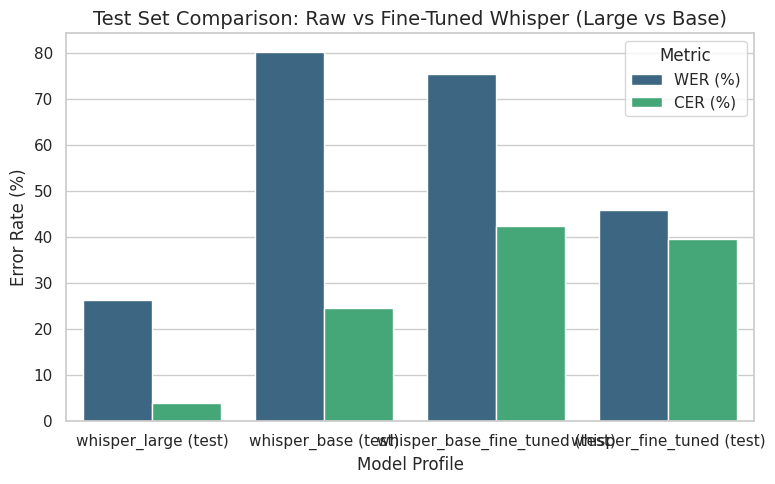

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results_file = "evaluation_results.json"

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        data = json.load(f)

    records = []
    targets = ["whisper_large (test)", "whisper_fine_tuned (test)", "whisper_base (test)", "whisper_base_fine_tuned (test)"]
    for profile, metrics in data.items():
        if profile in targets:
            records.append({
                "Profile": profile,
                "WER (%)": metrics["avg_wer"] * 100,
                "CER (%)": metrics["avg_cer"] * 100
            })

    if len(records) > 0:
        df = pd.DataFrame(records)
        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(8, 5))

        df_melted = df.melt(id_vars="Profile", var_name="Metric", value_name="Score")
        sns.barplot(data=df_melted, x="Profile", y="Score", hue="Metric", ax=ax, palette="viridis")

        ax.set_title("Test Set Comparison: Raw vs Fine-Tuned Whisper (Large vs Base)", fontsize=14)
        ax.set_ylabel("Error Rate (%)")
        ax.set_xlabel("Model Profile")
        plt.tight_layout()
        plt.show()
    else:
        print("Please run the two evaluation cells above first.")
else:
    print("No evaluation_results.json found.")
